In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/kidney_disease.csv")
df.head()


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

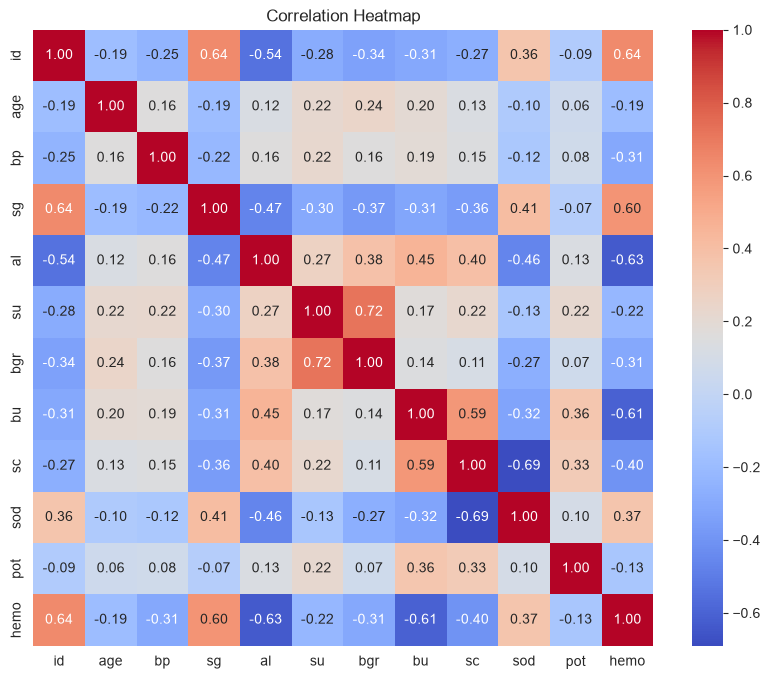

In [3]:
print(df.info())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass balance:\n", df['classification'].value_counts())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [4]:
df = df.drop('id', axis=1, errors='ignore')
df = df.replace('?', np.nan)
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

binary_cols = ['htn', 'dm', 'cad', 'pe', 'ane']
df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))
abnormal_cols = ['rbc', 'pc']
df[abnormal_cols] = df[abnormal_cols].apply(lambda col: col.map({'normal': 1, 'abnormal': 0}))
present_cols = ['pcc', 'ba']
df[present_cols] = df[present_cols].apply(lambda col: col.map({'present': 1, 'notpresent': 0}))
df['appet'] = df['appet'].map({'good': 1, 'poor': 0})
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0, 'ckd\t': 1})

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in df.columns:
    df[col] = df[col].fillna(df[col].median())

X = df.drop('classification', axis=1)
y = df['classification']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
models = {
    "random_forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "svm": SVC(probability=True, random_state=42),
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42)
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
    trained_models[name] = model

    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df



--- random_forest ---
[[30  0]
 [ 0 50]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


--- svm ---
[[30  0]
 [ 1 49]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


--- logistic_regression ---
[[30  0]
 [ 1 49]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   mac

C:\Users\VIKAS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,accuracy,precision,recall,f1
0,random_forest,1.0000,1.0,1.00,1.000000
1,svm,0.9875,1.0,0.98,0.989899
2,logistic_regression,0.9875,1.0,0.98,0.989899


In [6]:
os.makedirs('../models/kidney', exist_ok=True)

for name, model in trained_models.items():
    joblib.dump(model, f'../models/kidney/{name}.pkl')

joblib.dump(scaler, '../models/kidney/scaler.pkl')
results_df.to_json('../models/kidney/metrics.json', orient='records')

print("Saved all models, scaler, and metrics.")


Saved all models, scaler, and metrics.


In [7]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()


In [8]:
disease = "kidney"
best_model_name = "random_forest"   # <-- replace with your actual best model from results_df above

model = joblib.load(f'../models/{disease}/{best_model_name}.pkl')
scaler = joblib.load(f'../models/{disease}/scaler.pkl')

df = pd.read_csv("C:/Users/VIKAS/Desktop/Disease_Prediction_Project/data/kidney_disease.csv")
df = df.drop('id', axis=1, errors='ignore')
df = df.replace('?', np.nan)
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

binary_cols = ['htn', 'dm', 'cad', 'pe', 'ane']
df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))
abnormal_cols = ['rbc', 'pc']
df[abnormal_cols] = df[abnormal_cols].apply(lambda col: col.map({'normal': 1, 'abnormal': 0}))
present_cols = ['pcc', 'ba']
df[present_cols] = df[present_cols].apply(lambda col: col.map({'present': 1, 'notpresent': 0}))
df['appet'] = df['appet'].map({'good': 1, 'poor': 0})
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0, 'ckd\t': 1})

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in df.columns:
    df[col] = df[col].fillna(df[col].median())

X = df.drop('classification', axis=1)
feature_names = X.columns.tolist()
X_scaled = scaler.transform(X)


In [9]:
# Tree-based models (RandomForest, XGBoost, DecisionTree) -> TreeExplainer (fast)
# Others (LogisticRegression, SVM, KNN, Naive Bayes) -> KernelExplainer (slower, needs background sample)

tree_models = ["random_forest", "xgboost", "decision_tree"]

if best_model_name in tree_models:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_scaled)
    # For binary classifiers, shap_values may be a list [class0, class1] -> take class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background = shap.sample(X_scaled, 100, random_state=42)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(X_scaled[:100])  # limit rows, KernelExplainer is slow


<Figure size 640x480 with 0 Axes>

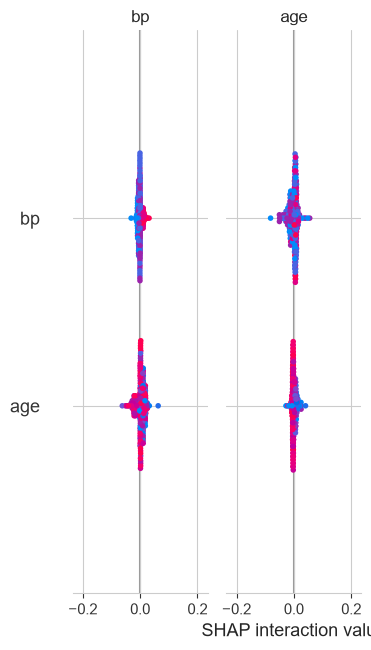

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_scaled if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_bar.png', dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

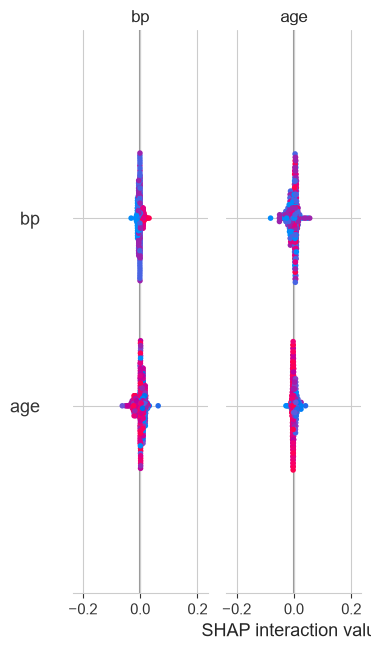

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_scaled if best_model_name in tree_models else X_scaled[:100],
                   feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(f'../models/{disease}/shap_summary_beeswarm.png', dpi=150)
plt.show()


In [12]:
def explain_single_prediction(patient_row_scaled, explainer, feature_names, is_tree_model):

    # Get SHAP values
    if is_tree_model:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]  # take first sample

    else:
        sv = explainer.shap_values(patient_row_scaled)

        # Binary classification case
        if isinstance(sv, list):
            sv = sv[1]

        sv = sv[0]

    # Important fix
    sv = np.array(sv).reshape(-1)   # ensures 1D

    # Create dataframe
    impact_df = pd.DataFrame({
        "feature": feature_names,
        "shap_value": sv
    })

    impact_df["abs_impact"] = impact_df["shap_value"].abs()

    return impact_df.sort_values("abs_impact", ascending=False)
